Project root: /Users/mac/Desktop/DSS5104_Assignment2
PyTorch version: 2.11.0
Using device: cpu
Raw features: 47
Engineered features: 17
Total features: 64

Train shape: (472432, 470)
Test shape: (118108, 470)
Train fraud rate: 0.0351
Test fraud rate: 0.0344
X_train shape: (472432, 64)
X_test shape: (118108, 64)
Train missing values: 3433954
Test missing values: 817332
Filling missing values...
X_train shape after scaling: (472432, 64)
X_test shape after scaling: (118108, 64)
Training set size: 377,946
Validation set size: 94,486
Input dimension: 64
Training Supervised Neural Network
Epoch 20/200, Train Loss: 0.0126, Val Loss: 0.0143
Epoch 40/200, Train Loss: 0.0111, Val Loss: 0.0142
Epoch 60/200, Train Loss: 0.0098, Val Loss: 0.0145
Early stopping at epoch 61

Test Results:
  AUPRC: 0.4887
  ROC AUC: 0.9046

Using cost-optimal threshold (0.0708):
  Precision: 0.0495
  Recall: 0.9806
  F1: 0.0943


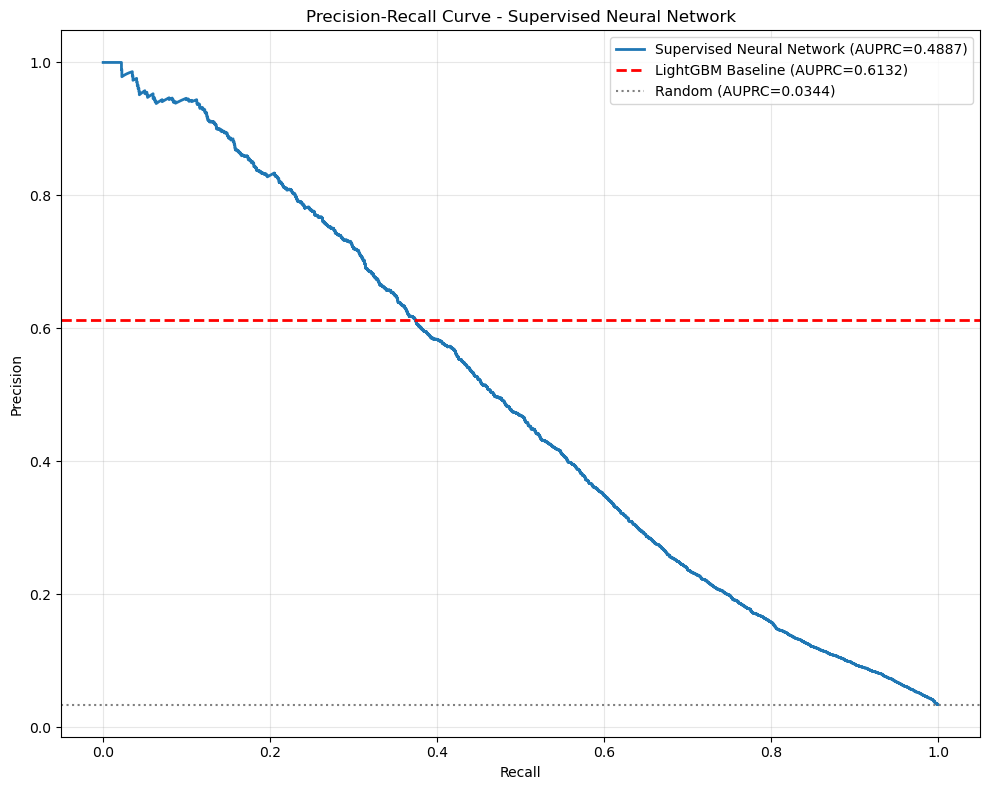

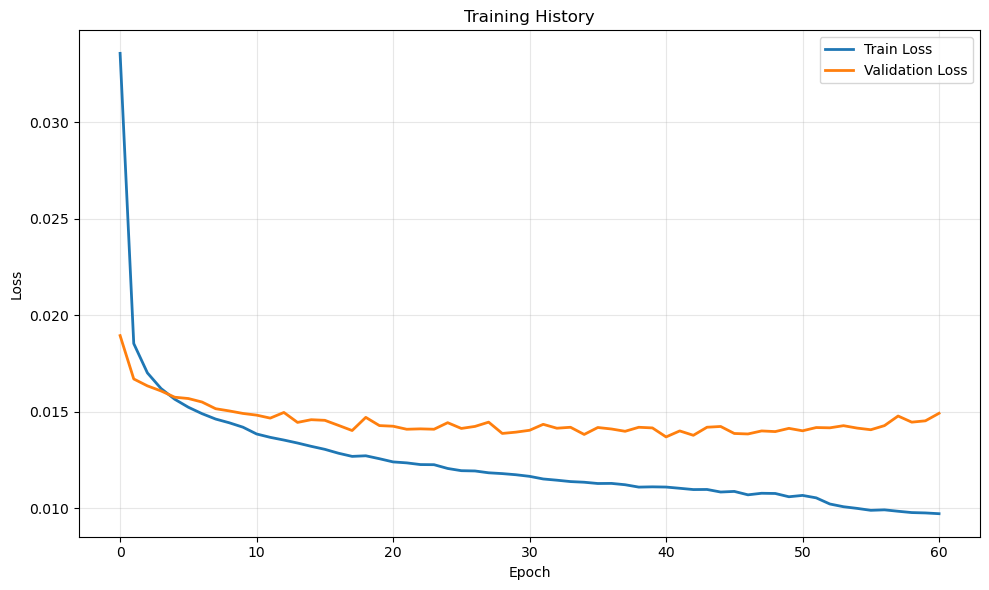


Results Summary
                    Model    AUPRC  ROC AUC  Precision@0.0708  Recall@0.0708
Supervised Neural Network 0.488745 0.904608          0.049525       0.980561
        LightGBM Baseline 0.613200 0.943100          0.067300       0.981300

✅ Supervised Neural Network training complete!


In [ ]:
# # 07. Supervised Deep Learning for Fraud Detection
# ## Supervised Neural Network
# ### 1. Environment Setup & Data Loading

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_processed_data(dataset='ieee'):
    """Load pre-processed data from processed folder"""
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    
    train = pd.read_parquet(data_dir / f'{dataset}_train.parquet')
    test = pd.read_parquet(data_dir / f'{dataset}_test.parquet')
    
    # Load feature lists from dataset_info.json
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    
    return train, test, raw_cols, eng_cols, all_cols

# Load data
train_ieee, test_ieee, raw_cols, eng_cols, all_cols = load_processed_data('ieee')

print(f"Raw features: {len(raw_cols)}")
print(f"Engineered features: {len(eng_cols)}")
print(f"Total features: {len(all_cols)}")
print(f"\nTrain shape: {train_ieee.shape}")
print(f"Test shape: {test_ieee.shape}")
print(f"Train fraud rate: {train_ieee['isFraud'].mean():.4f}")
print(f"Test fraud rate: {test_ieee['isFraud'].mean():.4f}")

# ### 2. Feature Preparation

# Extract features and labels
X_train_raw = train_ieee[all_cols].values
X_test_raw = test_ieee[all_cols].values
y_train = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

# Handle missing values
print(f"Train missing values: {np.isnan(X_train_raw).sum()}")
print(f"Test missing values: {np.isnan(X_test_raw).sum()}")

if np.isnan(X_train_raw).sum() > 0:
    print("Filling missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median


# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")


In [ ]:

# ### 3. Define Model

class FraudDetectionNet(nn.Module):
    """Neural network for fraud detection"""
    def __init__(self, input_dim, hidden_dims=[256, 128, 64, 32], dropout_rate=0.3):
        super(FraudDetectionNet, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


class FocalLoss(nn.Module):
    """Focal Loss for imbalanced classification"""
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        p_t = inputs * targets + (1 - inputs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_weight = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_weight * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

# ### 4. Training Function

def train_model(X_train, y_train, X_val, y_val, input_dim,
                epochs=200, batch_size=4096, lr=0.001,
                patience=20, verbose=True):
    """Train neural network"""
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val).to(device)
    
    # Create DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    model = FraudDetectionNet(input_dim).to(device)
    
    # Loss function
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)
        
        epoch_train_loss /= len(X_train)
        train_losses.append(epoch_train_loss)
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor).squeeze()
            val_loss = criterion(val_outputs, y_val_tensor).item()
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

# ### 5. Train Model

# Split validation set (keep temporal order, use last 20% as validation)
val_size = int(len(X_train) * 0.2)
X_train_sub = X_train[:-val_size]
y_train_sub = y_train[:-val_size]
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

print(f"Training set size: {len(X_train_sub):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"Input dimension: {X_train.shape[1]}")

print("="*60)
print("Training Supervised Neural Network")
print("="*60)

model, train_losses, val_losses = train_model(
    X_train_sub, y_train_sub, X_val, y_val,
    input_dim=X_train.shape[1],
    epochs=200,
    batch_size=4096,
    lr=0.001,
    patience=20,
    verbose=True
)

# ### 6. Evaluation

# Predict
X_test_tensor = torch.FloatTensor(X_test).to(device)
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_tensor).squeeze().cpu().numpy()

# Calculate metrics
auprc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Results:")
print(f"  AUPRC: {auprc:.4f}")
print(f"  ROC AUC: {roc_auc:.4f}")

# Use cost-optimal threshold (0.0708)
optimal_threshold = 0.0708
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nUsing cost-optimal threshold ({optimal_threshold}):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1: {f1:.4f}")



In [ ]:

# ### 7. Visualization

# PR Curve
fig, ax = plt.subplots(figsize=(10, 8))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ax.plot(recall_curve, precision_curve, linewidth=2, 
        label=f'Supervised Neural Network (AUPRC={auprc:.4f})')

# LightGBM baseline
ax.axhline(y=0.6132, color='red', linestyle='--', linewidth=2,
           label=f'LightGBM Baseline (AUPRC=0.6132)')

# Random baseline
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle=':', linewidth=1.5,
           label=f'Random (AUPRC={baseline:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Supervised Neural Network')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'supervised_nn_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train Loss', linewidth=2)
ax.plot(val_losses, label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training History')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ### 8. Results Summary

results_summary = pd.DataFrame({
    'Model': ['Supervised Neural Network', 'LightGBM Baseline'],
    'AUPRC': [auprc, 0.6132],
    'ROC AUC': [roc_auc, 0.9431],
    'Precision@0.0708': [precision, 0.0673],
    'Recall@0.0708': [recall, 0.9813],
})

print("\n" + "="*60)
print("Results Summary")
print("="*60)
print(results_summary.to_string(index=False))
